In [9]:
!pip install "cellpose[all]" opencv-python-headless pandas matplotlib
!mkdir -p ./data ./output/masks ./output/overlays
!unzip -q data.zip -d ./data

In [10]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cellpose import models, utils
from tqdm import tqdm

# --- Configuration ---
DATA_DIR = './data'
OVERLAY_DIR = './output/overlays'
MIN_CELL_AREA = 150
ESTIMATED_DIAMETER = 30

# Initialize the Cellpose model
# Using 'cyto3' for state-of-the-art cytoplasmic segmentation
model = models.CellposeModel(gpu=True, model_type='cyto3')

results = []

# Recursively find all image files regardless of directory nesting
image_paths = []
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith(('.tif', '.png', '.jpg')):
            image_paths.append(os.path.join(root, f))

# Verify file discovery
if len(image_paths) == 0:
    print("Error: No images found. Please check your data directory path.")
else:
    print(f"Found {len(image_paths)} images. Starting processing...")

    for img_path in tqdm(image_paths, desc="Counting Cells"):
        img_name = os.path.basename(img_path)

        # Parse metadata from filename
        # Expected format: CellLine_Well_Timepoint
        try:
            name_no_ext = os.path.splitext(img_name)[0]
            # Handling both '-' and '_' as delimiters
            parts = np.split(np.array(name_no_ext.replace('-', '_').split('_')), [3])[0]
            cell_line, well, timepoint = parts[0], parts[1], parts[2]
        except Exception:
            cell_line, well, timepoint = "Unknown", "Unknown", "Unknown"

        # Read image in grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # Model evaluation
        # net_avg and resample are enabled by default for high precision
        masks, flows, styles = model.eval(img, diameter=ESTIMATED_DIAMETER)

        # Post-processing: Filter by area to remove debris/noise
        outlines = utils.outlines_list(masks)
        valid_count = 0
        clean_mask = np.zeros_like(masks)

        for i, outline in enumerate(outlines):
            mask_idx = masks == (i + 1)
            area = np.sum(mask_idx)
            if area >= MIN_CELL_AREA:
                valid_count += 1
                clean_mask[mask_idx] = valid_count

        # Aggregate results
        results.append({
            'Image': img_name,
            'Cell_Line': cell_line,
            'Well': well,
            'Timepoint': timepoint,
            'Cell_Count': valid_count
        })

        # Generate and save diagnostic visualizations
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.title('Original Brightfield')
        plt.imshow(img, cmap='gray')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title(f'Detected Cells: {valid_count}')
        plt.imshow(img, cmap='gray')
        # Overlay the mask with transparency
        plt.imshow(clean_mask > 0, alpha=0.3, cmap='jet')
        plt.axis('off')

        plt.tight_layout()
        plt.savefig(os.path.join(OVERLAY_DIR, f"overlay_{img_name}"))
        plt.close()

    # Export metrics to CSV for downstream analysis
    pd.DataFrame(results).to_csv('./output/cell_counts_final.csv', index=False)
    print("Pipeline finished successfully. All images processed.")

Found 80 images. Starting processing...


Counting Cells: 100%|██████████| 80/80 [28:39<00:00, 21.50s/it]

Pipeline finished successfully. All images processed.


Data validation: 36 records successfully parsed.
            Image Cell_Line  Hour  Cell_Count
0  UC-A12-t04.tif        UC     4         232
1   BM-C1-t10.tif        BM    10         292
2   AD-G5-t10.tif        AD    10         314
3   BM-C1-t28.tif        BM    28          11
4  UC-A12-t16.tif        UC    16         175


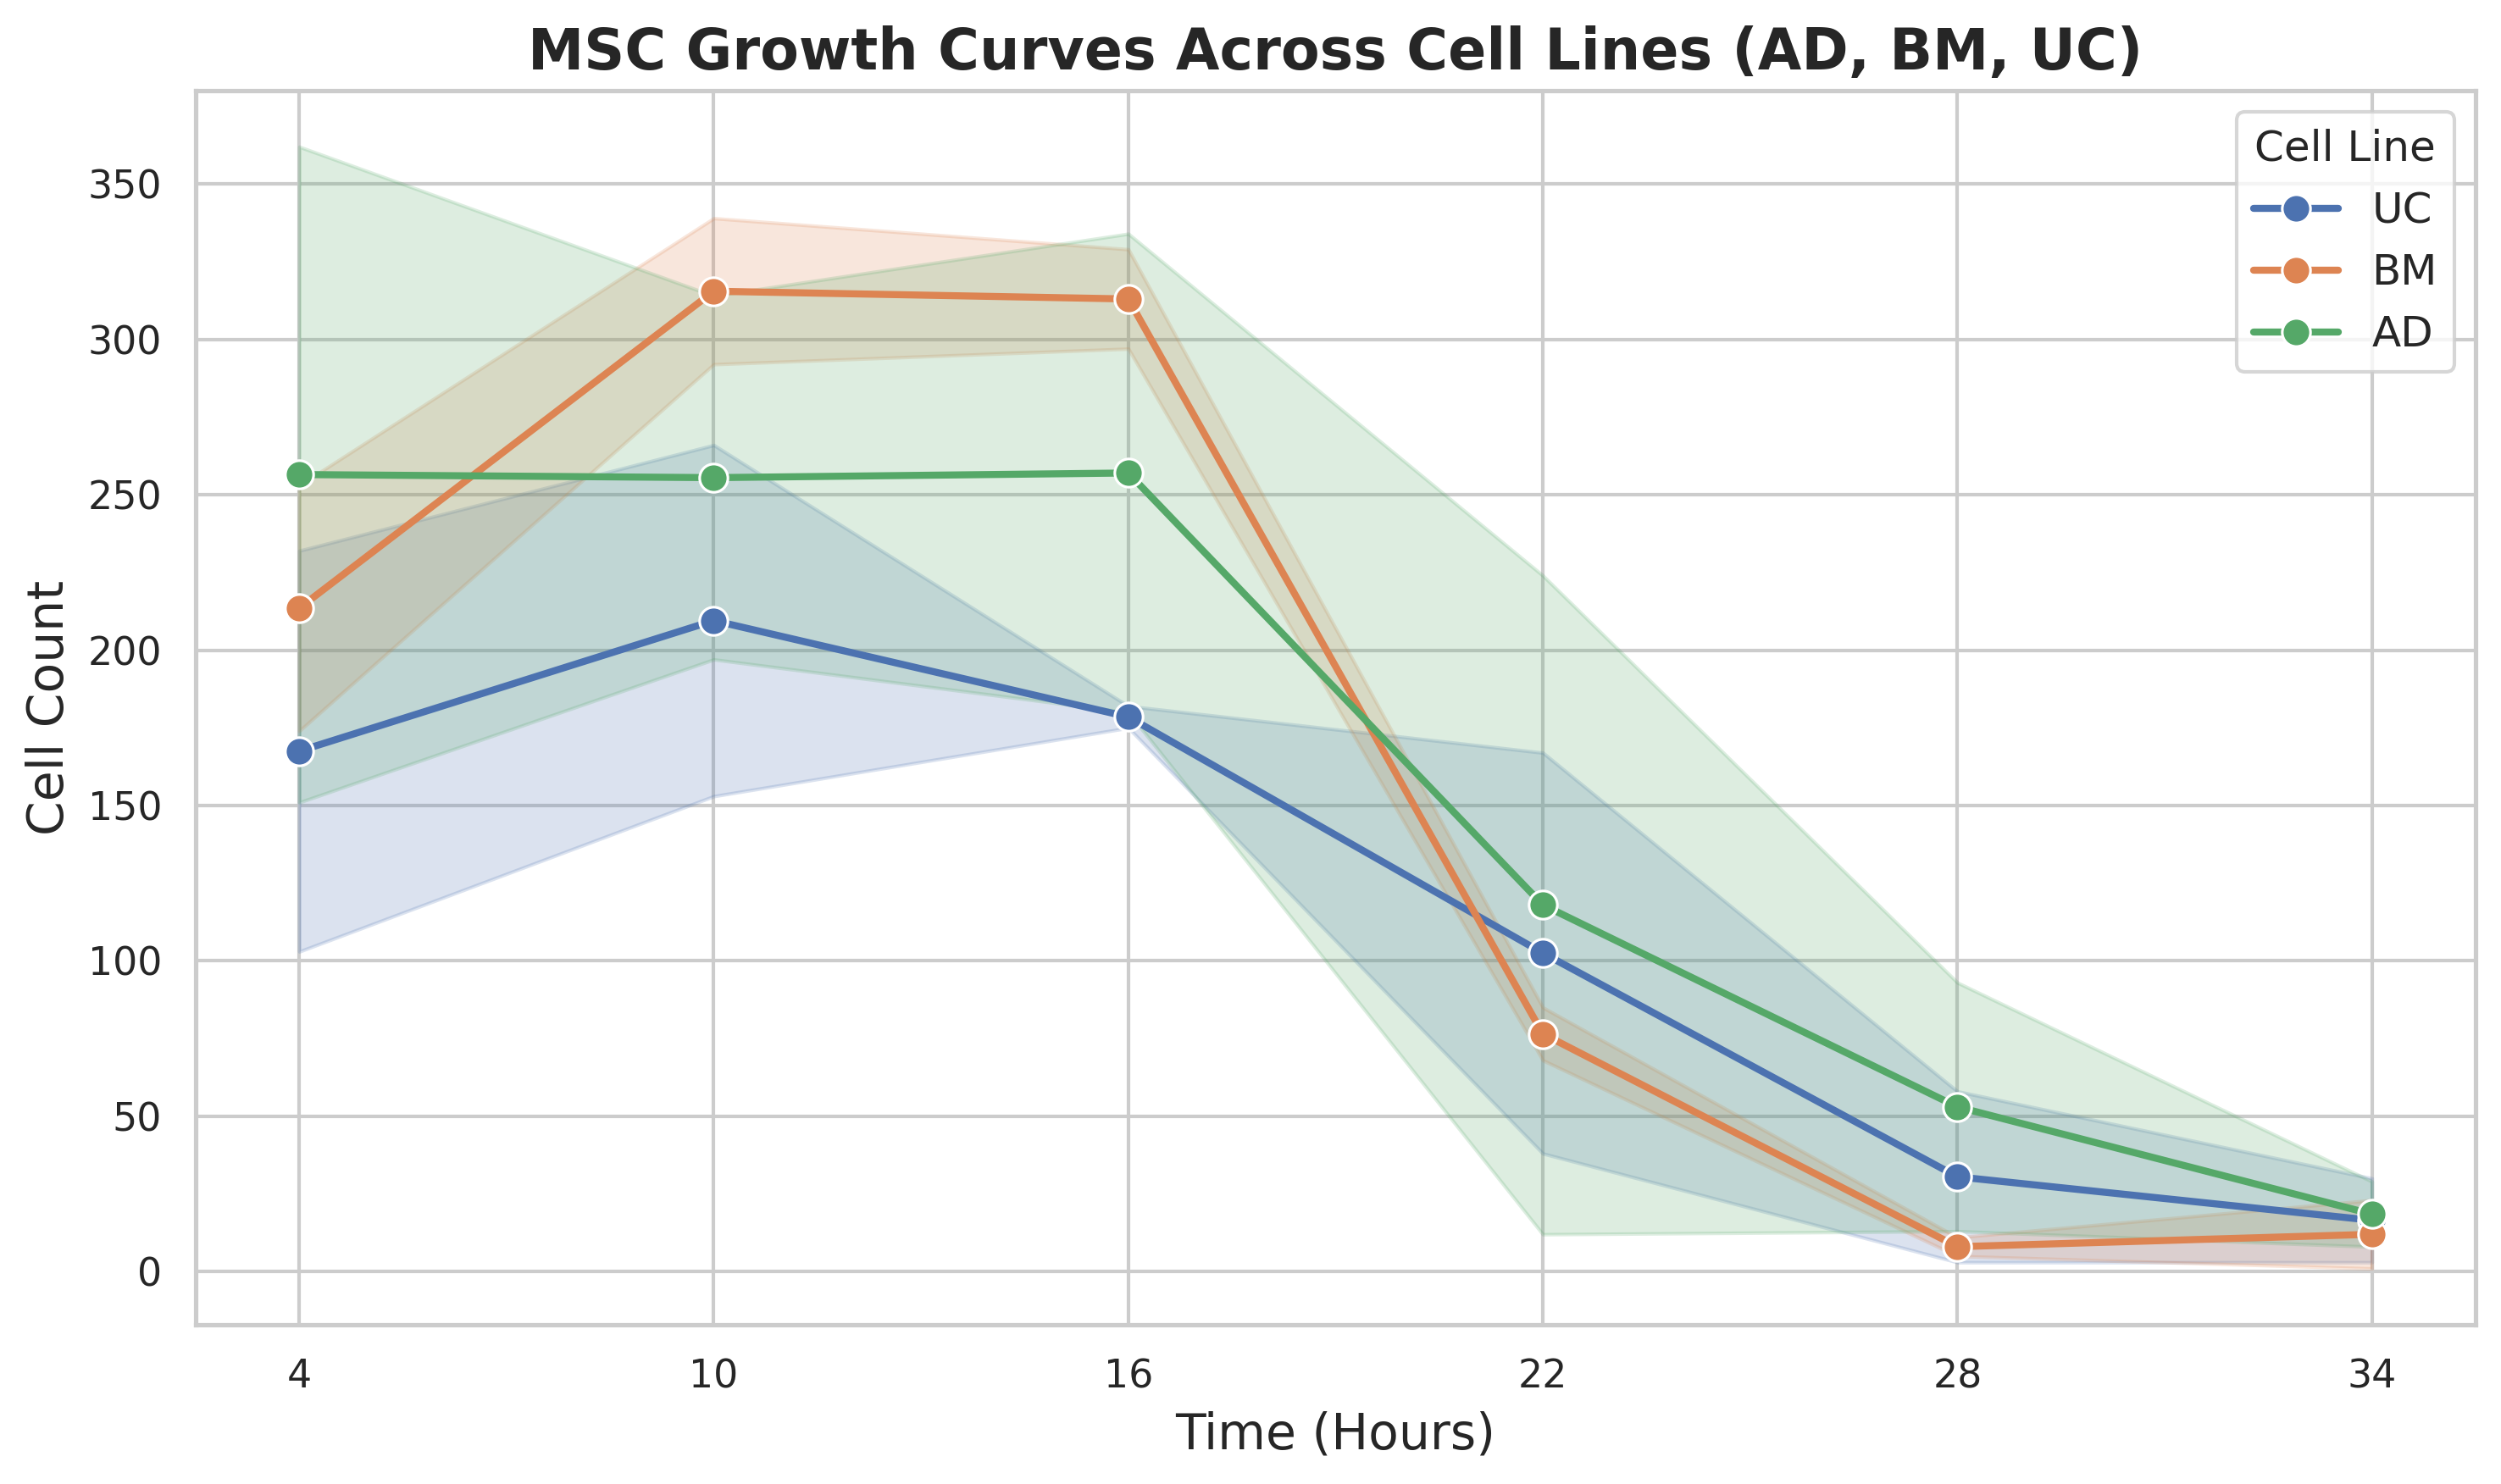

Visualization saved to: msc_growth_curve.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# 1. Load the generated dataset
# This file contains the 'Cell_Count' results and original 'Image' filenames
csv_path = './output/cell_counts_final.csv'
df = pd.read_csv(csv_path)

# 2. Metadata Reconstruction
# This function re-parses metadata directly from filenames to ensure accuracy,
# handling both '-' and '_' as delimiters.
def parse_metadata(filename):
    # Remove file extension
    name_no_ext = re.sub(r'\.(tif|png|jpg)$', '', str(filename), flags=re.IGNORECASE)
    # Split by hyphen or underscore
    parts = re.split(r'[-_]', name_no_ext)
    if len(parts) >= 3:
        return parts[0], parts[1], parts[2]
    return "Unknown", "Unknown", "Unknown"

# Correcting metadata columns in the dataframe
df[['Cell_Line', 'Well', 'Timepoint']] = df['Image'].apply(lambda x: pd.Series(parse_metadata(x)))

# 3. Temporal Data Extraction
# Converts timepoint strings (e.g., '04h' or 't04') into numerical integers for plotting.
def extract_hour(tp_str):
    match = re.search(r'\d+', str(tp_str))
    return int(match.group()) if match else None

df['Hour'] = df['Timepoint'].apply(extract_hour)

# Filter out records where Hour could not be parsed and enforce integer typing
df_growth = df.dropna(subset=['Hour']).copy()
df_growth['Hour'] = df_growth['Hour'].astype(int)

# Log data status for verification
print(f"Data validation: {len(df_growth)} records successfully parsed.")
print(df_growth[['Image', 'Cell_Line', 'Hour', 'Cell_Count']].head())

# 4. Professional Visualization
# Plotting growth curves with mean values and 95% confidence intervals (shadowed area)
plt.figure(figsize=(10, 6), dpi=300)
sns.set_theme(style="whitegrid")

# Using seaborn lineplot to aggregate multiple wells per cell line automatically
plot = sns.lineplot(
    data=df_growth,
    x='Hour',
    y='Cell_Count',
    hue='Cell_Line',
    marker='o',
    linewidth=2,
    markersize=8
)

# Standardizing plot aesthetics
plt.title('MSC Growth Curves Across Cell Lines (AD, BM, UC)', fontsize=16, fontweight='bold')
plt.xlabel('Time (Hours)', fontsize=14)
plt.ylabel('Cell Count', fontsize=14)
plt.xticks(sorted(df_growth['Hour'].unique()))

# Legend and layout configuration
plt.legend(title='Cell Line', fontsize=12, title_fontsize=12, loc='upper right')
plt.tight_layout()

# Exporting the visualization for the final report
output_plot_path = 'msc_growth_curve.png'
plt.savefig(output_plot_path)
plt.show()

print(f"Visualization saved to: {output_plot_path}")